In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame

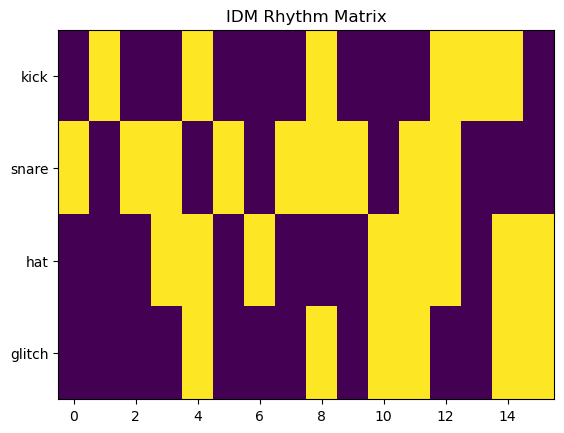

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
kick,0,1,0,0,1,0,0,0,1,0,0,0,1,1,1,0
snare,1,0,1,1,0,1,0,1,1,1,0,1,1,0,0,0
hat,0,0,0,1,1,0,1,0,0,0,1,1,1,0,1,1
glitch,0,0,0,0,1,0,0,0,1,0,1,1,0,0,1,1


In [2]:
df = DataFrame(
    np.random.randint(0, 2, (4,16)),
    index=["kick","snare", "hat", "glitch"]
)

plt.imshow(df, aspect="auto")
plt.yticks(range(len(df)), df.index)
plt.title("IDM Rhythm Matrix")
plt.show()

df

In [3]:
steps = 16
tracks = ["kick", "snare", "hat", "glitch"]

pattern = pd.DataFrame(
    np.zeros((len(tracks), steps), dtype=int),
    index=tracks,
    columns=range(steps)
)

pattern

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
kick,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
snare,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
hat,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
glitch,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


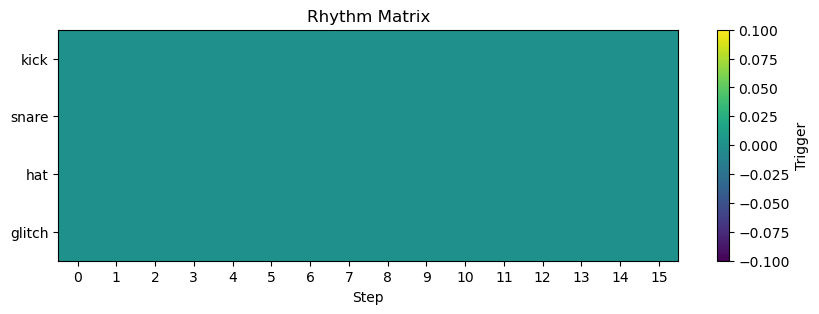

In [4]:
def plot_pattern(df, title="Rhythm Matrix"):
    plt.figure(figsize=(10,3))
    plt.imshow(df, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(df)), df.index)
    plt.xticks(range(len(df.columns)))
    plt.xlabel("Step")
    plt.title(title)
    plt.colorbar(label="Trigger")
    plt.show()

plot_pattern(pattern)


In [5]:
probabilities = {
    "kick": 0.25,
    "snare": 0.15,
    "hat": 0.6,
    "glitch": 0.08
}

def generate_pattern(steps, probabilities):
    tracks = list(probabilities.keys())
    data = []

    for track in tracks:
        row = (np.random.rand(steps) < probabilities[track]).astype(int)
        data.append(row)

    return pd.DataFrame(data, index=tracks, columns=range(steps))

pattern = generate_pattern(16, probabilities)
pattern


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
kick,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0
snare,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
hat,1,1,1,0,0,0,0,1,1,1,1,1,0,1,1,1
glitch,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


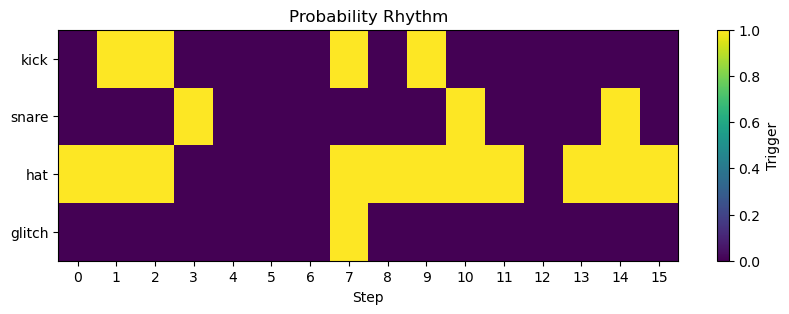

In [6]:
plot_pattern(pattern, "Probability Rhythm")


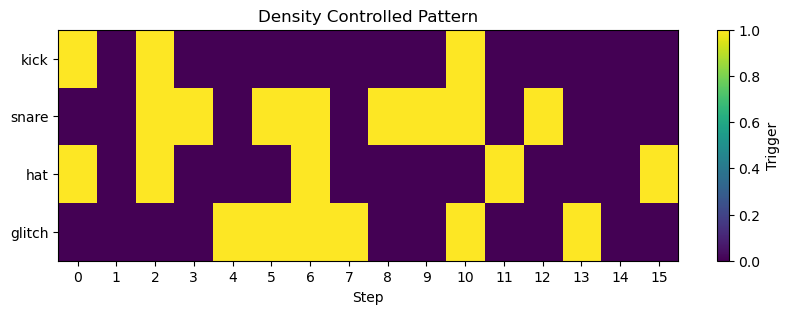

In [7]:
def generate_pattern_density(steps, tracks, density=0.3):
    mat = (np.random.rand(len(tracks), steps) < density).astype(int)
    return pd.DataFrame(mat, index=tracks, columns=range(steps))

pattern = generate_pattern_density(16, tracks, density=0.35)
plot_pattern(pattern, "Density Controlled Pattern")


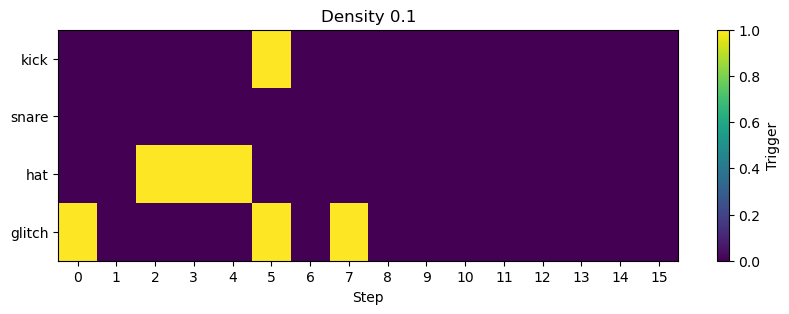

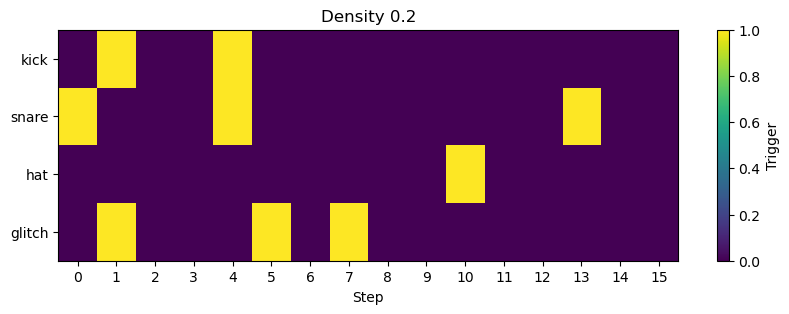

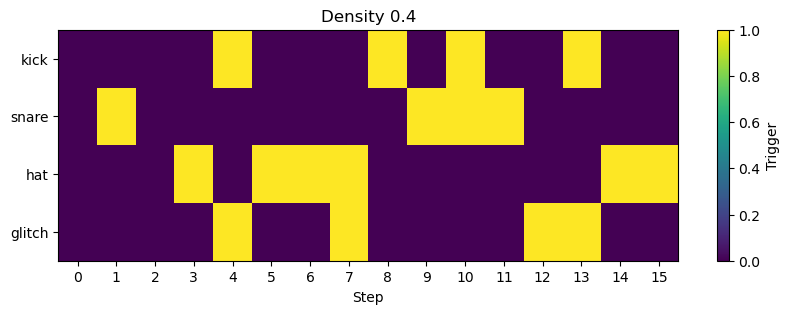

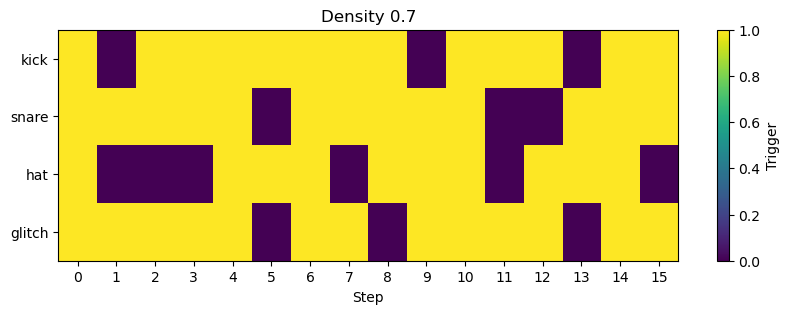

In [8]:
for d in [0.1, 0.2, 0.4, 0.7]:
    plot_pattern(generate_pattern_density(16, tracks, d), f"Density {d}")


In [11]:
def euclidean_rhythm(k, n):
    pattern = [1]*k + [0]*(n-k)
    while True:
        if len(pattern) <= 1:
            break
        first = pattern[0]
        rest = pattern[1:]
        if first == rest[-1]:
            break
        pattern = [pattern[i] + rest[i] if i < len(rest) else pattern[i]
                   for i in range(len(pattern))]
    return [int(x > 0) for x in pattern[:n]]


In [13]:
def euclidean_rhythm(k, n):
    if k > n: return [1] * n
    # Initialize pulses (1s) and rests (0s)
    groups = [[1]] * k + [[0]] * (n - k)
    
    while len(groups) > 1:
        # Determine how many remainders we have
        last_group_val = groups[-1]
        count = 0
        while count < len(groups) and groups[count] != last_group_val:
            count += 1
        
        # If no more pairs can be made, stop
        if count == 0 or count == len(groups): break
            
        # Combine the remainder groups with the main groups
        new_groups = []
        remainder = groups[count:]
        for i in range(len(remainder)):
            new_groups.append(groups[i] + remainder[i])
        
        # Add any leftover items that couldn't be paired
        if count > len(remainder):
            new_groups.extend(groups[len(remainder):count])
            
        groups = new_groups

    # Flatten the nested lists into a single rhythm list
    return [item for sublist in groups for item in sublist]




In [20]:
# Probabilistic mutation: randomly flips steps
def mutate_pattern(pattern, mutation_rate=0.1):
    mutated = pattern.copy()
    for track in pattern.index:
        row = mutated.loc[track].astype(int).values
        mask = (np.random.rand(len(row)) < mutation_rate).astype(int)
        mutated.loc[track] = row ^ mask
    return mutated


def markov_evolve(pattern, influence=0.3):
    evolved = pattern.copy()
    for track in pattern.index:
        row = evolved.loc[track].astype(int).values
        for i in range(1, len(row)):
            if np.random.rand() < influence:
                row[i] = row[i-1]
        evolved.loc[track] = row
    return evolved



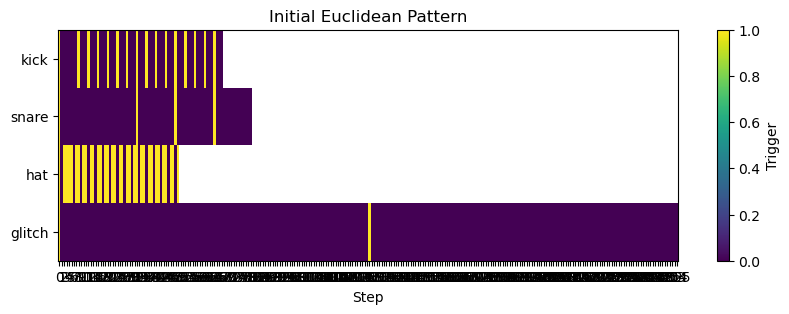

In [21]:
tracks = ["kick","snare","hat","glitch"]
steps = 16

# Euclidean starting pattern
kick = euclidean_rhythm(5, 16)
snare = euclidean_rhythm(3, 16)
hat = euclidean_rhythm(11, 16)
glitch = euclidean_rhythm(2, 16)

pattern = pd.DataFrame([kick, snare, hat, glitch], index=tracks)
plot_pattern(pattern, "Initial Euclidean Pattern")
